In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path

In [2]:
mode = "RADIAL_ONLY" # "RADIAL_ONLY" or "FULL_2D"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode)

In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j


In [4]:
# mesh_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Meshes")
mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

# figure_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Figures")
figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field()
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode)

Lz_plasma = 1.62e-01m, Lz_pml = 1.00e-01m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
N_pml_layer: 1.0
PPW_pml_target: 50.0
PPW_plasma: 8.00
dx_pml: 0.0100 m
Lx_pml: 0.01, Lx_plasma: 0.04
norm_x(0): 0.000
PPW_local: 50.00
lambda_meshing: 9.021e-03

Layer 0 at position 0.04000, h_local: 1.80e-04.
It's i == N_pml_layer - 1:

[MESH BUILDER - RADIAL_ONLY] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
  --> PML Stratified Adaptive Mesh Enabled (1 layers)
  --> PML Target PPW: 50
#DoFs = 1292411 (= number of mesh points).
Stretch_z (RADIAL_ONLY) : coef unary operation ' ', real
  coef 1, real

kz:1.55e+02
--- Solving the 3D vector linear system ---
  --> Success | Gamma_Radial: 5.0867e-02 | Gamma_Toroidal: 1.26e-02


In [6]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260602_141432
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260602_141432


In [7]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, mode)


--- Extracting 2D Wave Map ---
params recover in run_2D_wave_map
  --> Safely interpolating FEM fields onto structured grid...
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
PP_run_n_save: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260602_141432/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
--- 2D Map saved to /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260602_141432/Wave_Map_2D.h5 ---


--- Plotting 2D Map from /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260602_141432/Wave_Map_2D.h5 ---


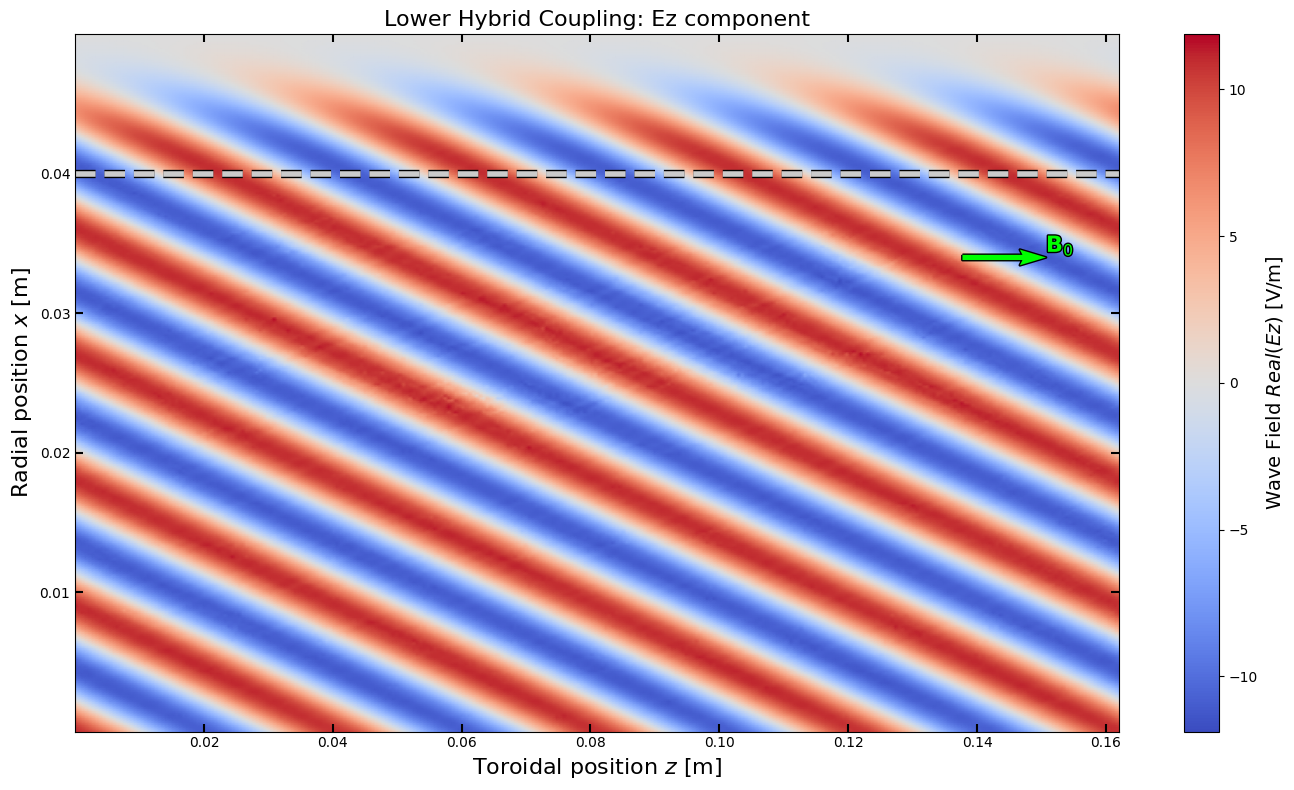

In [8]:
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 

# Plot E field 2D map and save it in the same folder: Run_XXX 
pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, mode, component='Ez', value_type='real', plot_poynting=False)

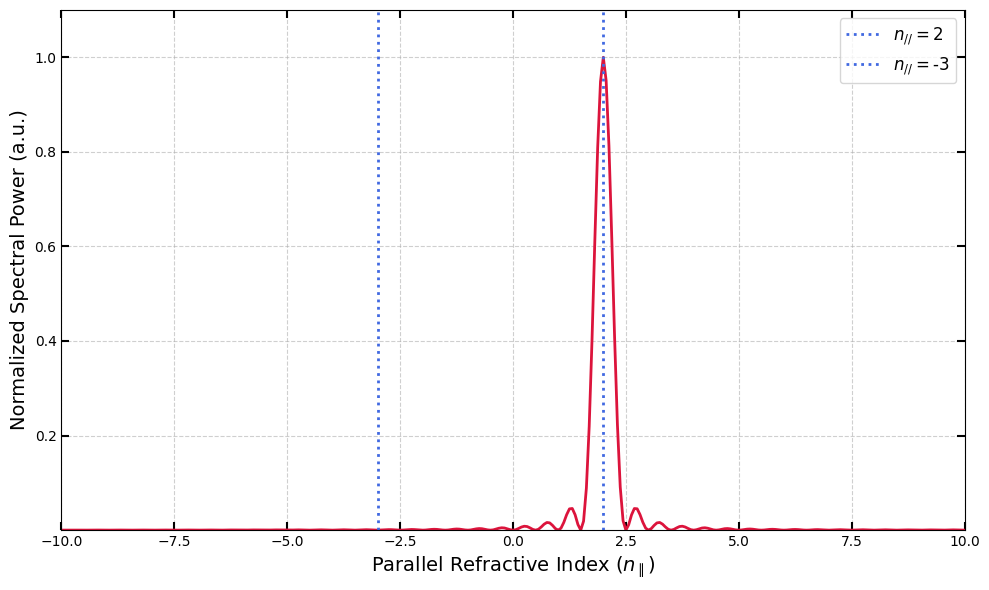

In [9]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, mode, x_eval=0.001)


  STARTING RIGOROUS 1D PML SENSITIVITY ANALYSIS

---> Scanning Parameter: ppw_pml
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lz_plasma = 1.62e-01m, Lz_pml = 1.00e-01m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
N_pml_layer: 1.0
PPW_pml_target: 8.0
PPW_plasma: 8.00
dx_pml: 0.0100 m
Lx_pml: 0.01, Lx_plasma: 0.04
norm_x(0): 0.000
PPW_local: 8.00
lambda_meshing: 9.021e-03

Layer 0 at position 0.04000, h_local: 1.13e-03.
It's i == N_pml_layer - 1:

[MESH BUILDER - RADIAL_ONLY] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
  --> PML Stratified Adaptive Mesh Enabled (1 layers)
  --> PML Target PPW: 8.0
#DoFs = 138064 (= number of mesh points).
Stretch_z (RADIAL_ONLY) : coef unary operation ' ', real
  coef 1, real

kz:1.55e+02
--- Solving the 3D vector linear system ---
  --> Success | Gamma_Radial: 3.1950e-02

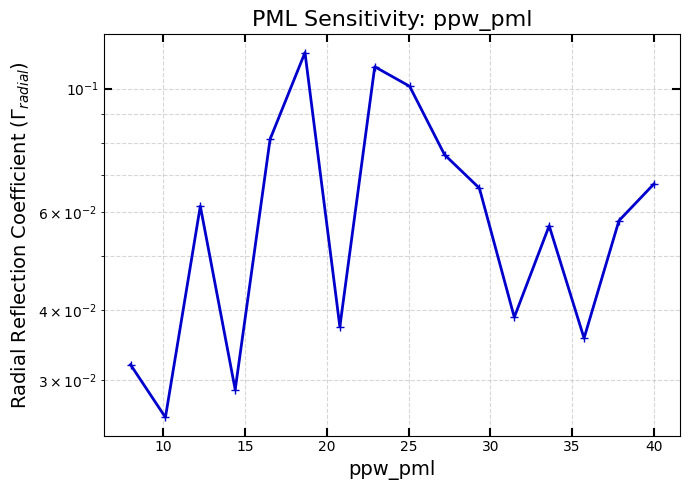


---> Scanning Parameter: Lx_pml_ratio
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lz_plasma = 1.62e-01m, Lz_pml = 1.00e-01m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
N_pml_layer: 1.0
PPW_pml_target: 50.0
PPW_plasma: 8.00
dx_pml: 0.0009 m
Lx_pml: 0.0009020789025193011, Lx_plasma: 0.04
norm_x(0): 0.000
PPW_local: 50.00
lambda_meshing: 9.021e-03

Layer 0 at position 0.04000, h_local: 1.80e-04.
It's i == N_pml_layer - 1:

[MESH BUILDER - RADIAL_ONLY] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
  --> PML Stratified Adaptive Mesh Enabled (1 layers)
  --> PML Target PPW: 50
#DoFs = 253212 (= number of mesh points).
Stretch_z (RADIAL_ONLY) : coef unary operation ' ', real
  coef 1, real

kz:1.55e+02
--- Solving the 

In [ ]:
# --- TEST PML PARAMS SENSIBILITY ---
# Sx_r, Sx_Im, px, Lx_pml_ratio (in lmin(ambda_perp)), ne, B,
import numpy as np
import matplotlib.pyplot as plt
import copy
import gc
from ngsolve import *
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def run_comprehensive_pml_scan(base_cfg, scan_dict, num_points_eval=500):
    """
    Rigorously sweeps PML parameters and computes the Radial Reflection Coefficient.
    
    :param base_cfg: The baseline configuration dictionary (cfg.__dict__ or pure dict).
    :param scan_dict: Dictionary of parameters to scan, e.g., {'Sx_im': np.linspace(0.1, 10, 20)}
    """
    print("=====================================================")
    print("  STARTING RIGOROUS 1D PML SENSITIVITY ANALYSIS")
    print("=====================================================")
    
    results = {}

    for param_name, param_values in scan_dict.items():
        print(f"\n---> Scanning Parameter: {param_name}")
        gamma_array = []
        
        for val in param_values:
            # 1. Safely Deep Copy the pure data dictionary to avoid polluting the baseline
            scan_cfg = {}
            for key, value in base_cfg.items():
                if isinstance(value, dict) and not key.startswith('__'):
                    scan_cfg[key] = copy.deepcopy(value)
            
            # 2. Inject the scanned parameter
            if param_name == 'Sx_r':
                scan_cfg['PML']['Sx_r'] = val
            elif param_name == 'ppw_pml':
                scan_cfg['PML']['ppw_pml'] = val
            elif param_name =='n_resol_per_wlgth': 
                scan_cfg['DOMAIN']['n_resol_per_wlgth'] = val 
            elif param_name == 'Sx_Im':
                scan_cfg['PML']['Sx_im'] = val
            elif param_name == 'px':
                scan_cfg['PML']['px'] = val
            elif param_name == 'Lx_pml_ratio':
                lambda0 = scan_cfg['WAVE']['lambda0']
                
                # We need a temporary solver just to run the Stix math 
                temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="RADIAL_ONLY")
                _, n_perp_p, _ = temp_solver.compute_physics_parameters()
                
                lambda_perp = lambda0 / np.abs(n_perp_p.real)
                actual_Lx_pml = val * lambda_perp
                
                scan_cfg['DOMAIN']['Lx_pml'] = actual_Lx_pml
                scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + actual_Lx_pml
                
                # Delete temp solver
                del temp_solver
            else:
                raise ValueError(f"Unknown scan parameter: {param_name}")

            # 3. Initialize and Run the Physics Solver
            solver = None
            mesh = None
            gfu = None
            Gamma_E = 1.0 # Default to total reflection if it crashes
            
            try:
                solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="RADIAL_ONLY")
                solver.compute_physics_parameters()
                mesh = solver.build_mesh_with_PMLs()
                solver.build_physics_Stix_B_field()
                gfu, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, scan_cfg)
                
                # 4. Rigorous Gamma Extraction
                # We extract the field in the middle 50% of the plasma to avoid 
                # antenna near-field effects and PML boundary evanescent modes.
                Lx_plasma = scan_cfg['DOMAIN']['Lx_plasma']
                Lz_plasma = scan_cfg['DOMAIN']['Lz_plasma']
                
                x_vals = np.linspace(Lx_plasma * 0.25, Lx_plasma * 0.75, num_points_eval)
                z_mid = Lz_plasma / 2.0
                
                E_3D_full = CF((gfu.components[0][0], gfu.components[1], gfu.components[0][1]))
                
                E_tot_norm = []
                for x in x_vals:
                    try:
                        val = E_3D_full(mesh(x, z_mid))
                        norm = np.sqrt(abs(val[0])**2 + abs(val[1])**2 + abs(val[2])**2)
                        E_tot_norm.append(norm)
                    except:
                        pass
                
                if len(E_tot_norm) > 0:
                    E_max = np.max(E_tot_norm)
                    E_min = np.max([np.min(E_tot_norm), 1e-12]) # Prevent division by zero
                    SWR = E_max / E_min
                    Gamma_E = (SWR - 1.0) / (SWR + 1.0)
                print(f'param_name: {param_name}, type(param_name): {type(param_name)}')
                print(f'type(val): {type(val)}')
                print(f'val: {val}')
                print(f"  [{param_name} = {val}]")
                print(f"-> Gamma: {Gamma_E:.2e}")
                
            except Exception as e:
                print(f"  [{param_name} = {val}] -> FAILED: {e}")
                Gamma_E = 1.0 # Assume 100% reflection on failure
                
            finally:
                gamma_array.append(Gamma_E)
                # 5. ABSOLUTE MEMORY DESTRUCTION (Prevents NGSolve RAM Overflow)
                if mesh is not None: del mesh
                if gfu is not None: del gfu
                if solver is not None: del solver
                gc.collect()

        results[param_name] = (param_values, gamma_array)
        
        # 6. Generate Plot for this parameter
        if param_name == 'Sx_r':
            color_curve = "seagreen"
        elif param_name == 'ppw_pml':
            color_curve = "mediumblue"
        elif param_name == 'Sx_Im':
            color_curve = "darkorchid"
        elif param_name == 'px':
            color_curve = "firebrick"
        elif param_name == 'Lx_pml_ratio':
            color_curve = "dodgerblue"
        else:
            color_curve ="darkorange"
        plt.figure(figsize=(7, 5))
        plt.plot(param_values, gamma_array, marker='+', linestyle='-', color=color_curve, lw=2)
        plt.yscale('log')
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        
        xlabel_str = param_name
        if param_name == 'Lx_pml_ratio':
            xlabel_str = r"PML Depth Ratio ($L_{pml} / \lambda_\perp$)"
        elif param_name == 'Sx_Im':
            xlabel_str = r"Imaginary Stretching ($S_x^{im}$)"
        elif param_name == 'Sx_r':
            xlabel_str = r"Real Stretching ($S_x^r$)"
        elif param_name == 'px':
            xlabel_str = r"Polynomial Degree ($p_x$)"
            
        plt.xlabel(xlabel_str, fontsize=14)
        plt.ylabel(r"Radial Reflection Coefficient ($\Gamma_{radial}$)", fontsize=14)
        plt.title(f"PML Sensitivity: {param_name}", fontsize=16)
        plt.tick_params(direction='in', length=6, width=1.5, bottom=True, top=True, right=True, left=True)

        plt.tight_layout()
        plt.show()

scans_to_run = {
    'ppw_pml': np.linspace(8., 40, 16), 
    'Lx_pml_ratio': np.linspace(.1, 5.0, 10),
    'n_resol_per_wlgth' : np.linspace(1, 25, 25),
    'Sx_Im': np.linspace(0.1, 10.0, 25), 
    'Sx_r': np.linspace(0.1, 10.0, 25), 
    'px': np.linspace(0.1, 4.0, 25), 

         
}

scan_results = run_comprehensive_pml_scan(cfg.__dict__, scans_to_run)